# Minimum Lens System Search

**Problem**: Find the minimum number of lenses to focus a circular Gaussian beam
to a target waist at a given position.

| Parameter | Value |
|-----------|-------|
| Wavelength λ | 1.064 µm |
| Input waist w₀ | 2.0 mm |
| Target position z | 200 mm |
| Target waist w | 0.1 mm |
| Waist tolerance Δz | ±10 mm |
| Lens type | spherical (f can be negative) |

**Key challenge**: The Rayleigh range of the input beam is
z_R = π w₀² / λ ≈ 11,820 mm ≫ z_target = 200 mm,
so the beam is nearly collimated at z = 200 mm without optics.
A single converging lens cannot hit the 0.1 mm target at this distance
— at least **2 lenses** are required.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from gbeampro import GaussBeam, OpticalSystem, Propagation
from gbeampro.optimize import waist_operands, find_minimum_system, build_xy_systems
import gbeampro.plot as gplot
import gbeampro.analysis as ga
import gbeampro
print('gbeampro version:', gbeampro.__version__)

gbeampro version: 2.0.0


## Problem Setup

In [2]:
WL       = 1.064   # µm
W0       = 2.0     # mm
Z_TARGET = 200.0   # mm
W_TARGET = 0.1     # mm
WAIST_TOL = 10.0   # mm  (acceptable waist displacement)

beam = GaussBeam.from_waist(wl_um=WL, w0_mm=W0)
print(beam)

z_R = np.pi * W0**2 / (WL * 1e-3)
w_at_target = beam.w_mm * np.sqrt(1 + (Z_TARGET / z_R)**2)
print(f'\nRayleigh range:       z_R = {z_R:.0f} mm')
print(f'Beam size at z=200mm: w   = {w_at_target*1e3:.2f} µm  (without optics)')
print(f'Target:               w   = {W_TARGET*1e3:.0f} µm')

GaussBeam(wl_um=1.064, n=1.0, z_mm=0.00000, R_mm=inf, w_mm=2.00000)
  q = 0.00000e+00-1.18105e+04j  theta = 0.1693 mrad

Rayleigh range:       z_R = 11810 mm
Beam size at z=200mm: w   = 2000.29 µm  (without optics)
Target:               w   = 100 µm


## Minimum Lens Search

`find_minimum_system` tries n = 1, 2, 3, ... lenses and stops
at the first n where `merit < merit_threshold`.

- `f_bounds=(-10000, 10000)`: negative focal lengths (diverging lenses) are allowed
- `min_lens_sep_mm=20`: adjacent lenses must be ≥ 20 mm apart
- `waist_tol_x/y_mm`: sets curvature weight so Δz = ±10 mm is treated
  as equivalent to the size tolerance

In [3]:
operands = waist_operands(
    z_mm=Z_TARGET, wx_mm=W_TARGET, wy_mm=W_TARGET,
    size_weight=1.0,
    waist_tol_x_mm=WAIST_TOL,
    waist_tol_y_mm=WAIST_TOL,
)

print(f'Merit function operands:')
for op in operands:
    print(f'  {op.type:<4}  z={op.z_mm:.0f} mm  target={op.target:.4g}  weight={op.weight:.3g}')
print()

result, n_min = find_minimum_system(
    beam, operands,
    lens_type='spherical',
    max_lenses=5,
    merit_threshold=1e-3,
    min_lens_sep_mm=20.0,
    f_bounds=(-10000, 10000),
    algorithm='de',
    verbose=True,
)

Merit function operands:
  wx    z=200 mm  target=0.1  weight=1
  wy    z=200 mm  target=0.1  weight=1
  cvx   z=200 mm  target=0  weight=4
  cvy   z=200 mm  target=0  weight=4



n=1  merit=9.335e+01  operands=[0.6038, 0.6038, -0.01154, -0.01154]


n=2  merit=7.414e-14  operands=[0.1, 0.1, 4.103e-10, 4.103e-10]


## Optimized System

In [4]:
print(f'Minimum configuration: {n_min} lens(es)  merit = {result.merit:.3e}')
print()
print(f"{'#':>2}  {'Type':<12}  {'z (mm)':>10}  {'f (mm)':>10}")
print('   ' + '-' * 38)
for i, s in enumerate(result.specs, 1):
    ftype = 'converging' if s['f_mm'] > 0 else 'diverging'
    print(f"{i:>2}  {s['type']:<12}  {s['z_mm']:>10.2f}  {s['f_mm']:>10.2f}  ({ftype})")

print()
print('Operand summary:')
print(f"  {'type':<4}  {'target':>10}  {'achieved':>10}  {'error':>10}")
print('  ' + '-' * 42)
for op, val in zip(operands, result.operand_values):
    err = val - op.target
    print(f"  {op.type:<4}  {op.target:>10.4g}  {val:>10.4g}  {err:>+10.2e}")

Minimum configuration: 2 lens(es)  merit = 7.414e-14

 #  Type              z (mm)      f (mm)
   --------------------------------------
 1  spherical           2.54      197.60  (converging)
 2  spherical         190.22      -12.35  (diverging)

Operand summary:
  type      target    achieved       error
  ------------------------------------------
  wx           0.1         0.1   +1.01e-08
  wy           0.1         0.1   +1.01e-08
  cvx            0   4.103e-10   +4.10e-10
  cvy            0   4.103e-10   +4.10e-10


## Caustic Plot

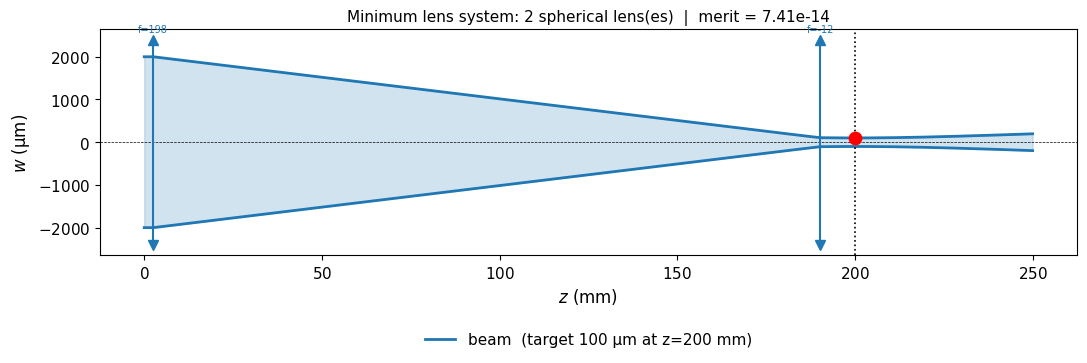

In [5]:
# Build system extended past z_target to visualize the waist
Z_END = Z_TARGET + 50
sx, sy = build_xy_systems(beam, result.specs, Z_END)
traj = sx.trace(beam, dz=0.5)

fig, ax = plt.subplots(figsize=(11, 4))
gplot.plot_system(sx, traj, ax, label=f'beam  (target {W_TARGET*1e3:.0f} µm at z={Z_TARGET:.0f} mm)')
ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2, label=f'z = {Z_TARGET:.0f} mm')
ax.scatter([Z_TARGET], [W_TARGET * 1e3], color='r', zorder=6, s=80, label='target waist')
ax.set_title(f'Minimum lens system: {n_min} spherical lens(es)  |  merit = {result.merit:.2e}')
plt.tight_layout()

## Waist Verification

## Case 2: Constrained |f| ∈ [30, 1000] mm

With `f_abs_bounds=(30, 1000)`, very short focal lengths (|f| < 30 mm) are excluded.
The solution found in Case 1 used f = −12.3 mm, which violates this constraint,
so a third lens is needed.

In [6]:
result2, n_min2 = find_minimum_system(
    beam, operands,
    lens_type='spherical',
    max_lenses=5,
    merit_threshold=1e-3,
    min_lens_sep_mm=20.0,
    f_abs_bounds=(30, 1000),
    algorithm='de',
    verbose=True,
)

n=1  merit=9.335e+01  operands=[0.6038, 0.6038, -0.01154, -0.01154]


n=2  merit=4.893e+00  operands=[0.2543, 0.2543, -0.0006408, -0.0006408]


n=3  merit=6.649e-17  operands=[0.1, 0.1, -1.434e-11, -1.434e-11]


In [7]:
print(f'Minimum configuration: {n_min2} lens(es)  merit = {result2.merit:.3e}')
print()
print(f"{'#':>2}  {'Type':<12}  {'z (mm)':>10}  {'f (mm)':>10}  {'|f| (mm)':>10}")
print('   ' + '-' * 48)
for i, s in enumerate(result2.specs, 1):
    ftype = 'converging' if s['f_mm'] > 0 else 'diverging'
    print(f"{i:>2}  {s['type']:<12}  {s['z_mm']:>10.2f}  {s['f_mm']:>10.2f}  {abs(s['f_mm']):>10.2f}  ({ftype})")

print()
print('Operand summary:')
print(f"  {'type':<4}  {'target':>10}  {'achieved':>10}  {'error':>10}")
print('  ' + '-' * 42)
for op, val in zip(operands, result2.operand_values):
    err = val - op.target
    print(f"  {op.type:<4}  {op.target:>10.4g}  {val:>10.4g}  {err:>+10.2e}")

Minimum configuration: 3 lens(es)  merit = 6.649e-17

 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical           9.41      132.40      132.40  (converging)
 2  spherical         113.98      -39.90       39.90  (diverging)
 3  spherical         185.78      -55.85       55.85  (diverging)

Operand summary:
  type      target    achieved       error
  ------------------------------------------
  wx           0.1         0.1   +5.87e-11
  wy           0.1         0.1   +5.87e-11
  cvx            0  -1.434e-11   -1.43e-11
  cvy            0  -1.434e-11   -1.43e-11


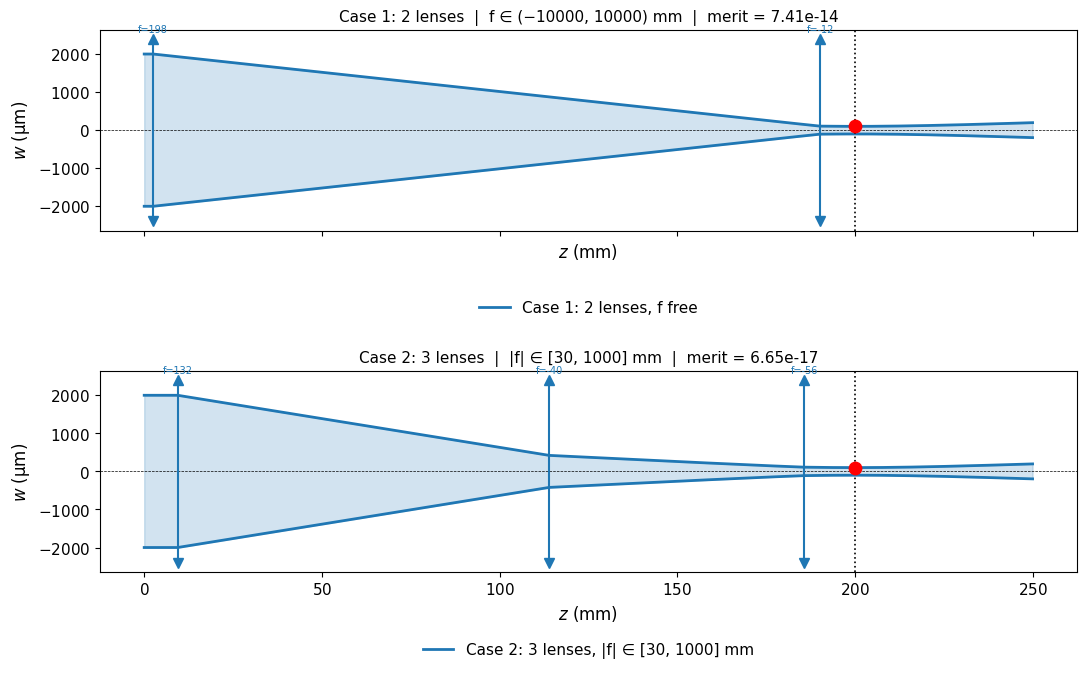

In [8]:
Z_END = Z_TARGET + 50
sx2, _ = build_xy_systems(beam, result2.specs, Z_END)
traj2 = sx2.trace(beam, dz=0.5)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
sx_orig, _ = build_xy_systems(beam, result.specs, Z_END)
traj_orig = sx_orig.trace(beam, dz=0.5)
gplot.plot_system(sx_orig, traj_orig, ax, label=f'Case 1: {n_min} lenses, f free')
ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
ax.scatter([Z_TARGET], [W_TARGET * 1e3], color='r', zorder=6, s=80, label='target')
ax.set_title(f'Case 1: {n_min} lenses  |  f ∈ (−10000, 10000) mm  |  merit = {result.merit:.2e}')

ax = axes[1]
gplot.plot_system(sx2, traj2, ax, label=f'Case 2: {n_min2} lenses, |f| ∈ [30, 1000] mm')
ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
ax.scatter([Z_TARGET], [W_TARGET * 1e3], color='r', zorder=6, s=80, label='target')
ax.set_title(f'Case 2: {n_min2} lenses  |  |f| ∈ [30, 1000] mm  |  merit = {result2.merit:.2e}')

plt.tight_layout()

In [9]:
waists = ga.find_waists(traj)
print('Detected waists:')
for w in waists:
    dz = w.z_mm - Z_TARGET
    dw = (w.w_mm - W_TARGET) / W_TARGET * 100
    zR = ga.rayleigh_range(w)
    print(f'  z = {w.z_mm:.2f} mm  (Δz = {dz:+.2f} mm)')
    print(f'  w₀ = {w.w_mm*1e3:.3f} µm  (error {dw:+.2f}%)')
    print(f'  z_R = {zR:.2f} mm  (2z_R = {2*zR:.2f} mm)')

print()
print('System summary:')
print(sx.summary(beam))

Detected waists:
  z = 200.18 mm  (Δz = +0.18 mm)
  w₀ = 100.002 µm  (error +0.00%)
  z_R = 29.53 mm  (2z_R = 59.05 mm)

System summary:


OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    2000.00         inf      169.34
   1  Propagation             2.541    2000.00   5.490e+07      169.34
   2  ThinLens                2.541    2000.00  -1.976e+02      169.34
   3  Propagation           190.215     105.35  -1.097e+01     3214.87
   4  ThinLens              190.215     105.35  -9.888e+01     3214.87
   5  Propagation           250.000     196.66   6.744e+01     1722.14
Beam waists:  z=200.006 mm (2w0=200.0 um)
